# Notebook 04 - Análisis de Componentes Principales (PCA)

**Proyecto Integrador - Minería de Datos I - Tec. Sup. Ciencia de Datos - ITSE**  
**Integrantes: Daniela Fernández - Julio Nahuel Gomez**

**Dataset:** Usuarios de plataforma de streaming  
**Objetivo:** Aplicar escalamiento y reducción de dimensionalidad mediante PCA.
Documentar las variables utilizadas, el escalamiento aplicado, la varianza explicada y la interpretación de las componentes obtenidas en relación con los hallazgos del EDA.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# ── CARGA DEL DATASET LIMPIO
df = pd.read_csv('https://raw.githubusercontent.com/Danielafz/PI_Mineria_Datos_I/main/data/processed/streaming_users_clean.csv')
df['last_login_date'] = pd.to_datetime(df['last_login_date']) #Convertimos last_login_date a fecha porque la vamos a usar en la siguiente celda para crear una variable nueva.

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 7003 filas, 8 columnas


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


## 1. **Preparación de variables para PCA** (Esta celda explicamos por qué necesitamos transformar las variables antes de aplicar PCA, usando los datos concretos que ya conocemos del dataset.)

PCA es un algoritmo que solo trabaja con variables numéricas. Al revisar nuestro
dataset identificamos que no todas las columnas cumplen esa condición:

- `subscription_plan`, `country` y `favorite_genre` son variables categóricas (texto).
- `last_login_date` es una variable de tipo fecha.
- `user_id` es un identificador único que no aporta información analítica.

Para poder incluirlas en el análisis aplicamos las siguientes transformaciones:

- `last_login_date` → se convierte en `dias_desde_login`: la cantidad de días
  transcurridos desde el último acceso del usuario. Un valor alto indica un usuario
  más inactivo.
- `subscription_plan`, `country` y `favorite_genre` → se codifican con
  **Label Encoding**, que asigna un número entero a cada categoría.
- `user_id` → se excluye del análisis.

**Limitación reconocida:** el Label Encoding en variables nominales como `country`
y `favorite_genre` introduce un orden numérico que no existe en los datos reales
(por ejemplo, Argentina=0 no es "menor" que Brasil=1). Para PCA esto es aceptable
porque el algoritmo trabaja con varianza, no con relaciones de orden.

In [12]:
#Preparación de variables

# ── 1. VARIABLE DE INACTIVIDAD DESDE LAST LOGIN
# Calculamos cuántos días pasaron desde el último login de cada usuario
fecha_referencia = pd.Timestamp('today').normalize()
df['dias_desde_login'] = (fecha_referencia - df['last_login_date']).dt.days.abs()

# ── 2. ENCODING DE VARIABLES CATEGÓRICAS
# Convertimos cada categoría en un número entero para que PCA pueda procesarlas
le = LabelEncoder()
for col in ['subscription_plan', 'country', 'favorite_genre']:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# ── 3. SELECCIÓN DE COLUMNAS PARA PCA
# Usamos solo las variables numéricas relevantes, excluimos user_id
columnas_pca = [
    'age',
    'monthly_watch_time_mins',
    'customer_support_tickets',
    'dias_desde_login',
    'subscription_plan_enc',
    'country_enc',
    'favorite_genre_enc'
]

df_pca = df[columnas_pca].copy()

# ── 4. VERIFICACIÓN
print("=== Variables que entran al PCA ===")
print(df_pca.dtypes)
print(f"\nShape: {df_pca.shape}")
print(f"\nValores nulos:\n{df_pca.isnull().sum()}")
df_pca.describe().round(2)

=== Variables que entran al PCA ===
age                           int64
monthly_watch_time_mins     float64
customer_support_tickets      int64
dias_desde_login              int64
subscription_plan_enc         int64
country_enc                   int64
favorite_genre_enc            int64
dtype: object

Shape: (7003, 7)

Valores nulos:
age                         0
monthly_watch_time_mins     0
customer_support_tickets    0
dias_desde_login            0
subscription_plan_enc       0
country_enc                 0
favorite_genre_enc          0
dtype: int64


,age,monthly_watch_time_mins,customer_support_tickets,dias_desde_login,subscription_plan_enc,country_enc,favorite_genre_enc
count,7003.00,7003.00,7003.00,7003.00,7003.00,7003.00,7003.00
mean,33.45,757.44,1.81,1608.53,0.75,3.00,2.92
std,11.76,367.78,11.66,845.28,0.76,1.99,2.00
min,0.00,0.00,0.00,178.00,0.00,0.00,0.00
25%,25.00,494.80,0.00,868.00,0.00,1.00,1.00
50%,33.00,758.90,1.00,1595.00,1.00,3.00,3.00
75%,41.00,1021.80,1.00,2346.00,1.00,5.00,5.00
max,80.00,2648.10,150.00,3099.00,2.00,6.00,6.00


## 2. **Escalamiento con StandardScaler**

Al observar la tabla anterior notamos que las variables tienen escalas muy distintas:
`dias_desde_login` tiene una media de 1608 mientras que `subscription_plan_enc`
tiene una media de 0.75. Si aplicáramos PCA directamente sobre estos datos,
`dias_desde_login` dominaría artificialmente las componentes principales solo
por tener valores más grandes, no por ser más informativa.

Para evitar esto aplicamos **StandardScaler**, que transforma cada variable para que tenga:
- **Media = 0**
- **Desviación estándar = 1**

De esta forma todas las variables parten en igualdad de condiciones y PCA puede
identificar correctamente cuáles concentran mayor varianza real en los datos.

In [13]:
# ── ESTANDARIZACIÓN CON STANDARDSCALER
# Transformamos todas las variables para que tengan media=0 y desvío estándar=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# ── VERIFICACIÓN DEL ESCALAMIENTO
# Comprobamos que todas las variables quedaron en la misma escala
medias  = X_scaled.mean(axis=0).round(4)
desvios = X_scaled.std(axis=0).round(4)

print("=== Resultado de la estandarización ===")
print(f"\nMedias (deben ser ≈ 0):")
for nombre, valor in zip(columnas_pca, medias):
    print(f"  {nombre}: {valor}")

print(f"\nDesviaciones estándar (deben ser ≈ 1):")
for nombre, valor in zip(columnas_pca, desvios):
    print(f"  {nombre}: {valor}")

=== Resultado de la estandarización ===

Medias (deben ser ≈ 0):
  age: -0.0
  monthly_watch_time_mins: 0.0
  customer_support_tickets: -0.0
  dias_desde_login: 0.0
  subscription_plan_enc: 0.0
  country_enc: 0.0
  favorite_genre_enc: -0.0

Desviaciones estándar (deben ser ≈ 1):
  age: 1.0
  monthly_watch_time_mins: 1.0
  customer_support_tickets: 1.0
  dias_desde_login: 1.0
  subscription_plan_enc: 1.0
  country_enc: 1.0
  favorite_genre_enc: 1.0


## 3. **Aplicación de PCA**

**¿Qué es PCA?**
El Análisis de Componentes Principales (PCA) es una técnica de reducción de
dimensionalidad. Transforma las 7 variables originales en nuevas variables llamadas
**componentes principales (PC)**, ordenadas de mayor a menor varianza explicada:
la PC1 captura la mayor cantidad de información posible del dataset, la PC2 la
siguiente, y así sucesivamente.

**¿Para qué lo aplicamos en este proyecto?**
En el EDA identificamos que el plan de suscripción es el factor más determinante
en el comportamiento de los usuarios, mientras que la edad no mostró relación con
el tiempo de visualización y los géneros se distribuyeron de forma homogénea entre
países. PCA nos permite confirmar y ampliar estos hallazgos: identificar qué
variables concentran mayor varianza en el dataset y si es posible representar
los datos en menos dimensiones sin perder información relevante.

In [16]:
# ── APLICACIÓN DE PCA CON TODAS LAS COMPONENTES
# Aplicamos PCA sobre los datos escalados para obtener las 7 componentes posibles
pca_full = PCA()
pca_full.fit(X_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# ── VARIANZA POR COMPONENTE
print("=== Varianza explicada por componente ===\n")
for i, (ve, va) in enumerate(zip(varianza_explicada, varianza_acumulada), 1):
    print(f"  PC{i}: {ve*100:.2f}%  |  Acumulada: {va*100:.2f}%")

# ── COMPONENTES NECESARIAS PARA SUPERAR 80% Y 90%
print()
for umbral in [0.80, 0.90]:
    n = np.argmax(varianza_acumulada >= umbral) + 1
    print(f"→ Se necesitan {n} componentes para explicar el {int(umbral*100)}% de la varianza")

=== Varianza explicada por componente ===

  PC1: 21.83%  |  Acumulada: 21.83%
  PC2: 14.64%  |  Acumulada: 36.47%
  PC3: 14.46%  |  Acumulada: 50.94%
  PC4: 14.31%  |  Acumulada: 65.25%
  PC5: 14.20%  |  Acumulada: 79.45%
  PC6: 13.81%  |  Acumulada: 93.25%
  PC7: 6.75%  |  Acumulada: 100.00%

→ Se necesitan 6 componentes para explicar el 80% de la varianza
→ Se necesitan 6 componentes para explicar el 90% de la varianza


## 4. **Visualización de la varianza explicada — Scree Plot**

El **Scree Plot** es el gráfico estándar para visualizar los resultados de PCA.
Muestra dos cosas:
- **Izquierda:** cuánta varianza explica cada componente por separado.
- **Derecha:** cómo se acumula esa varianza a medida que sumamos componentes.

Las líneas de referencia en el gráfico de la derecha marcan los umbrales del
**80%** (naranja) y **90%** (rojo), que son los criterios más usados para decidir
cuántas componentes conservar en un análisis.

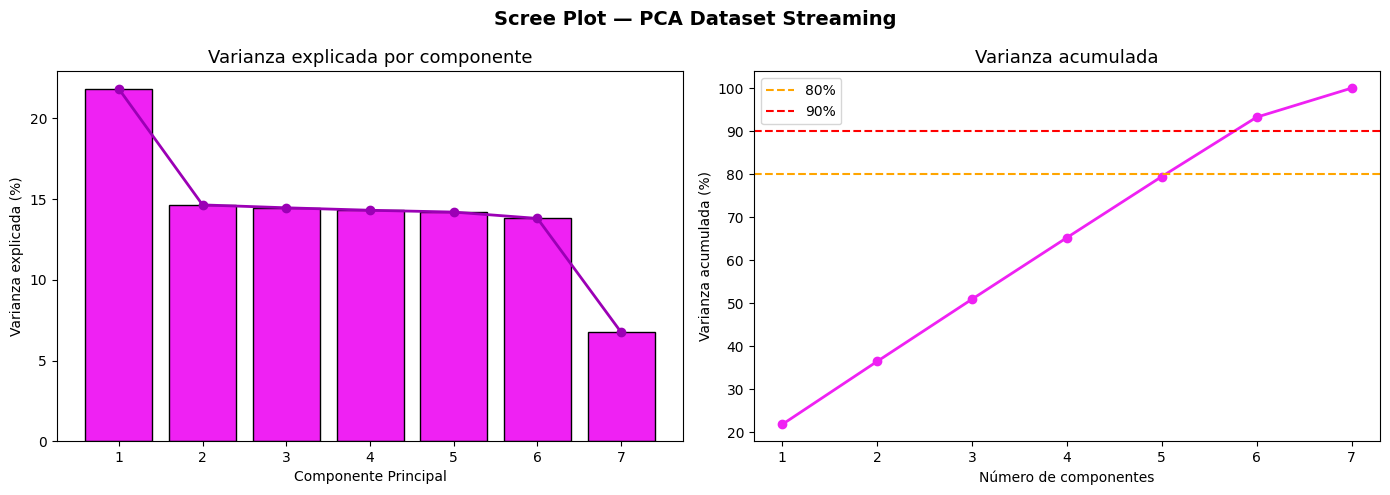

✔ Scree plot guardado.


In [18]:
# ── SCREE PLOT
# Visualizamos la varianza explicada por cada componente y la varianza acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

componentes = list(range(1, len(varianza_explicada) + 1))

# ── GRÁFICO IZQUIERDO: varianza individual por componente
ax1.bar(componentes, varianza_explicada * 100, color='#ef21f3', edgecolor='black')
ax1.plot(componentes, varianza_explicada * 100, 'o-', color='#9b00b5', linewidth=2)
ax1.set_title('Varianza explicada por componente', fontsize=13)
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza explicada (%)')
ax1.set_xticks(componentes)

# ── GRÁFICO DERECHO: varianza acumulada
ax2.plot(componentes, varianza_acumulada * 100, 'o-', color='#ef21f3', linewidth=2)
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=1.5, label='80%')
ax2.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90%')
ax2.set_title('Varianza acumulada', fontsize=13)
ax2.set_xlabel('Número de componentes')
ax2.set_ylabel('Varianza acumulada (%)')
ax2.set_xticks(componentes)
ax2.legend()

plt.suptitle('Scree Plot — PCA Dataset Streaming', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Scree plot guardado.")

## 5. Contribución de variables a cada componente — Heatmap de Loadings

Los **loadings** indican cuánto contribuye cada variable original a cada componente
principal. Un valor alto en rojo significa que esa variable tiene una contribución
positiva fuerte en esa componente. Un valor alto en azul indica contribución
negativa fuerte. Valores cercanos a cero indican que esa variable no influye
significativamente en esa componente.

Analizamos las primeras 3 componentes porque entre ellas explican el 50.94%
de la varianza total, y son las más interpretables del análisis.

=== Loadings — contribución de cada variable a cada componente ===
                            PC1    PC2    PC3
age                       0.000  0.204  0.667
monthly_watch_time_mins   0.707 -0.008  0.017
customer_support_tickets -0.016  0.241  0.365
dias_desde_login         -0.011  0.630 -0.399
subscription_plan_enc     0.707 -0.004 -0.010
country_enc               0.027  0.681 -0.107
favorite_genre_enc        0.001 -0.199 -0.501


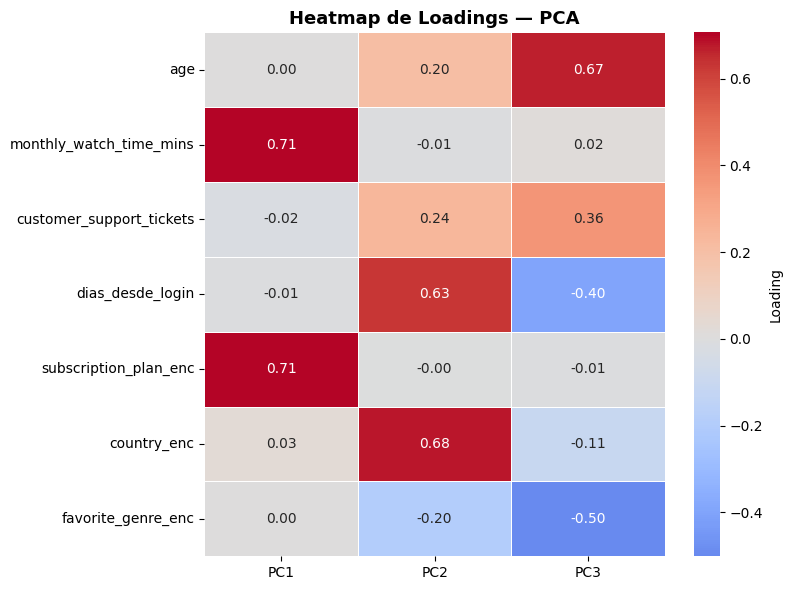

✔ Heatmap de loadings guardado.


In [19]:
# ── HEATMAP DE LOADINGS
# Calculamos los loadings de las primeras 3 componentes
# Los loadings indican cuánto contribuye cada variable a cada componente
n_componentes = 3
pca_final = PCA(n_components=n_componentes)
pca_final.fit(X_scaled)

loadings = pd.DataFrame(
    pca_final.components_.T,
    index   = columnas_pca,
    columns = [f'PC{i+1}' for i in range(n_componentes)]
)

print("=== Loadings — contribución de cada variable a cada componente ===")
print(loadings.round(3))

# ── VISUALIZACIÓN
plt.figure(figsize=(8, 6))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Loading'}
)
plt.title('Heatmap de Loadings — PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Heatmap de loadings guardado.")

## 6. Interpretación de resultados y conclusiones

### Varianza explicada
La varianza se distribuye de forma bastante pareja entre las 7 componentes.
La PC1 explica el 21.83% y las siguientes oscilan entre 13.81% y 14.64%.
Para superar el 80% de varianza acumulada se necesitan 5 componentes, y para
el 90% se necesitan 6. Esto indica que el dataset no tiene una estructura de
correlación fuerte entre variables: ninguna combinación de pocas variables
logra capturar la mayor parte de la información.

Este resultado es coherente con lo observado en el EDA, donde la correlación
entre edad y tiempo de visualización fue prácticamente cero (0.003), y los
géneros se distribuyeron de forma homogénea entre países sin patrones marcados.

### Interpretación de las componentes

**PC1 — Perfil de consumo (21.83% de la varianza)**
Está dominada por `monthly_watch_time_mins` (0.71) y `subscription_plan_enc`
(0.71). Esto significa que la primera componente captura principalmente el
comportamiento de consumo del usuario: cuánto contenido ve y qué plan tiene
contratado. Este resultado confirma el hallazgo más importante del EDA: el
plan de suscripción es el factor más determinante en el uso de la plataforma,
con usuarios Premium consumiendo casi el doble que los Básico.

**PC2 — Perfil geográfico y actividad (14.64% de la varianza)**
Está dominada por `country_enc` (0.68) y `dias_desde_login` (0.63). Esta
componente captura la combinación entre el país del usuario y su nivel de
actividad reciente. Un valor alto en PC2 indica un usuario de ciertos países
con mayor tiempo sin ingresar a la plataforma.

**PC3 — Perfil demográfico (14.46% de la varianza)**
Está dominada por `age` (0.67) y `favorite_genre_enc` (-0.50). Esta componente
asocia la edad del usuario con sus preferencias de género. A pesar de que en
el EDA la edad no mostró relación con el tiempo de visualización, sí aparece
como variable relevante al combinarse con el género favorito.

### Limitaciones
- La distribución pareja de varianza entre componentes indica que PCA no logra
  una reducción dimensional eficiente en este dataset. Esto se debe a que las
  variables tienen baja correlación entre sí.
- El Label Encoding en `country` y `favorite_genre` introduce un orden numérico
  artificial que puede afectar la interpretación de PC2 y PC3.
- `customer_support_tickets` presenta valores extremos (max 150) que, aunque
  se escalaron, pueden influir en los loadings observados.